In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("📚 Libraries loaded!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

📚 Libraries loaded!
Pandas version: 2.0.3
NumPy version: 1.24.4


### Loading Dataset

In [2]:
# Load data
data_path = r"D:\REHAAN\1. Ml Projects\6. Campus Energy Waste Detection\data\dataset.txt"

print("📂 Loading dataset...")
df = pd.read_csv(data_path, sep=';', low_memory=False)

print(f"✅ Dataset loaded!")
print(f"Shape: {df.shape}")
print(f"Size: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# First look
df.head()

📂 Loading dataset...
✅ Dataset loaded!
Shape: (2075259, 9)
Size: 2,075,259 rows × 9 columns
Memory usage: 1014.87 MB


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [3]:
# Dataset info
print("📊 DATASET OVERVIEW")
df.info()

print("\n📈 STATISTICS")
print(df.describe())

print("\n❓ MISSING VALUES")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing': missing,
    'Percentage': missing_pct
})
print(missing_df[missing_df['Missing'] > 0])

📊 DATASET OVERVIEW
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    object 
 3   Global_reactive_power  object 
 4   Voltage                object 
 5   Global_intensity       object 
 6   Sub_metering_1         object 
 7   Sub_metering_2         object 
 8   Sub_metering_3         float64
dtypes: float64(1), object(8)
memory usage: 142.5+ MB

📈 STATISTICS
       Sub_metering_3
count    2.049280e+06
mean     6.458447e+00
std      8.437154e+00
min      0.000000e+00
25%      0.000000e+00
50%      1.000000e+00
75%      1.700000e+01
max      3.100000e+01

❓ MISSING VALUES
                Missing  Percentage
Sub_metering_3    25979    1.251844


### Data Cleaning

In [10]:
# Replace '?' with NaN
print("Cleaning data...")
df = df.replace('?', np.nan)

# Convert columns to numeric
numeric_cols = ['Global_active_power', 'Global_reactive_power', 'Voltage', 
                'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Combine Date and Time
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S')
df = df.set_index('Datetime')
df = df.drop(['Date', 'Time'], axis=1)

# Sort by datetime
df = df.sort_index()

print(f"✅ Cleaned!")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"Duration: {(df.index.max() - df.index.min()).days} days")

df.head()

Cleaning data...


KeyError: 'Date'

### Handle Missing Values

In [5]:
# Check missing values after conversion
print("❓ Missing values after cleaning:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum():,} values")

# Strategy: Forward fill (reasonable for energy data)
print("\n🔧 Filling missing values...")
df = df.fillna(method='ffill')

# Drop any remaining NaNs
df = df.dropna()

print(f"✅ Final shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")

❓ Missing values after cleaning:
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

Total missing: 181,853 values

🔧 Filling missing values...
✅ Final shape: (2075259, 7)
Missing values: 0


## Initial Visualizations


In [6]:
# Time Series Plots

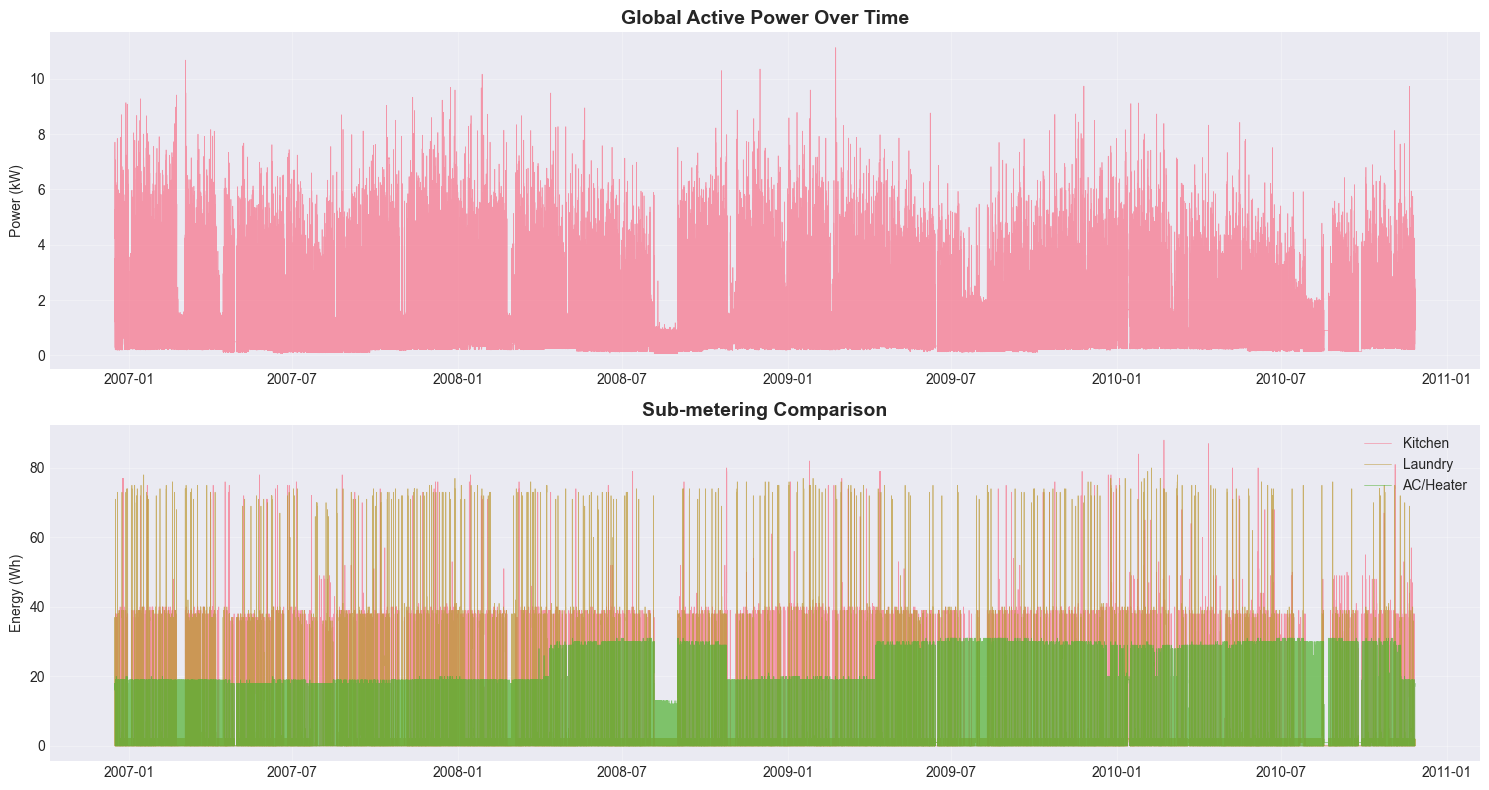

📊 Full time-series plotted!


In [7]:
# Plot overall consumption
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

# Global Active Power
axes[0].plot(df.index, df['Global_active_power'], linewidth=0.5, alpha=0.7)
axes[0].set_title('Global Active Power Over Time', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Power (kW)')
axes[0].grid(True, alpha=0.3)

# Sub-metering comparison
axes[1].plot(df.index, df['Sub_metering_1'], label='Kitchen', linewidth=0.5, alpha=0.7)
axes[1].plot(df.index, df['Sub_metering_2'], label='Laundry', linewidth=0.5, alpha=0.7)
axes[1].plot(df.index, df['Sub_metering_3'], label='AC/Heater', linewidth=0.5, alpha=0.7)
axes[1].set_title('Sub-metering Comparison', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Energy (Wh)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("📊 Full time-series plotted!")

In [8]:
# Quick Statistics

In [9]:
# Summary statistics
print("📈 CONSUMPTION STATISTICS")
print("="*60)
print(f"Mean consumption: {df['Global_active_power'].mean():.2f} kW")
print(f"Max consumption: {df['Global_active_power'].max():.2f} kW")
print(f"Min consumption: {df['Global_active_power'].min():.2f} kW")
print(f"Std deviation: {df['Global_active_power'].std():.2f} kW")

print("\n🏠 SUB-METERING BREAKDOWN")
print("="*60)
for col in ['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']:
    print(f"{col}: {df[col].mean():.2f} Wh (mean)")

📈 CONSUMPTION STATISTICS
Mean consumption: 1.09 kW
Max consumption: 11.12 kW
Min consumption: 0.08 kW
Std deviation: 1.05 kW

🏠 SUB-METERING BREAKDOWN
Sub_metering_1: 1.11 Wh (mean)
Sub_metering_2: 1.29 Wh (mean)
Sub_metering_3: 6.42 Wh (mean)


# Feature Engineering + EDA

In [ ]:
#Extract Time Features

In [11]:
# Create time-based features
print("🕐 Extracting time features...")

df['Hour'] = df.index.hour
df['Day'] = df.index.day
df['Month'] = df.index.month
df['Year'] = df.index.year
df['DayOfWeek'] = df.index.dayofweek  # 0=Monday, 6=Sunday
df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)
df['Quarter'] = df.index.quarter
df['DayOfYear'] = df.index.dayofyear

# Time of day categories
def categorize_time(hour):
    if 0 <= hour < 6:
        return 'Night'
    elif 6 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 18:
        return 'Afternoon'
    else:
        return 'Evening'

df['TimeOfDay'] = df['Hour'].apply(categorize_time)

print("✅ Time features created!")
print(f"\nNew columns: {list(df.columns[-9:])}")
df.head()

🕐 Extracting time features...
✅ Time features created!

New columns: ['Hour', 'Day', 'Month', 'Year', 'DayOfWeek', 'IsWeekend', 'Quarter', 'DayOfYear', 'TimeOfDay']


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Hour,Day,Month,Year,DayOfWeek,IsWeekend,Quarter,DayOfYear,TimeOfDay
Datetime,,,,,,,,,,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,17,16,12,2006,5,1,4,350,Afternoon
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,17,16,12,2006,5,1,4,350,Afternoon
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,17,16,12,2006,5,1,4,350,Afternoon
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,17,16,12,2006,5,1,4,350,Afternoon
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,17,16,12,2006,5,1,4,350,Afternoon


In [12]:
# Hourly Patterns Analysis

📊 Resampling to hourly data...
Original shape: (2075259, 16)
Hourly shape: (34589, 15)
Reduced to: 34,589 hours

⏰ HOURLY CONSUMPTION PATTERNS
          mean       std    min     max
Hour                                   
0     0.659583  0.715571  0.078   7.698
1     0.540739  0.584391  0.078  10.290
2     0.482724  0.488542  0.078   6.248
3     0.447379  0.430958  0.078   4.426
4     0.446164  0.425918  0.078   4.796
5     0.455703  0.446219  0.078   6.376
6     0.788972  0.924235  0.078   8.310
7     1.490076  1.080738  0.078   9.486
8     1.449551  0.950159  0.078   8.126
9     1.322167  0.855760  0.078   7.732
10    1.252229  0.904988  0.078   9.078
11    1.237853  1.001172  0.078   8.504
12    1.199247  1.063483  0.078   9.224
13    1.137712  1.045174  0.078   9.590
14    1.077447  1.025481  0.078   8.418
15    0.987055  0.998472  0.078   8.848
16    0.945568  0.951844  0.078   8.446
17    1.050723  1.033362  0.078  11.122
18    1.317963  1.200297  0.078   9.724
19    1.721268  1

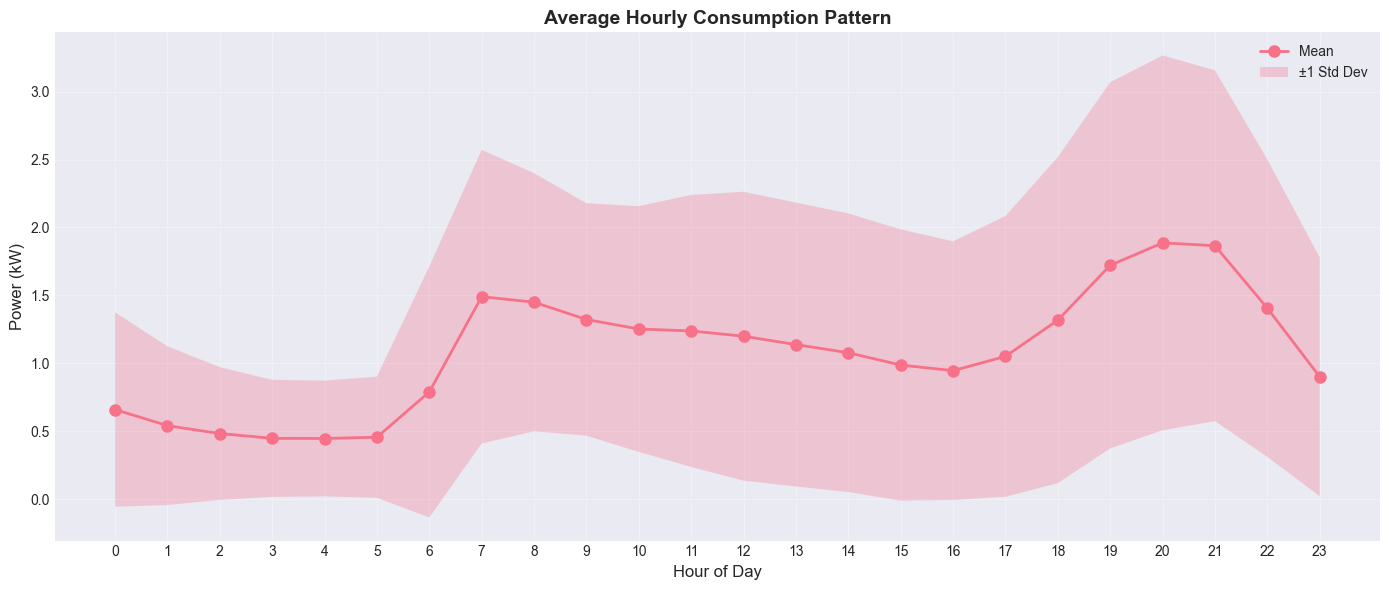


🔥 Peak consumption: 20:00 (1.89 kW)
💤 Lowest consumption: 4:00 (0.45 kW)


In [14]:
# Resample to hourly data (easier to work with)
print("📊 Resampling to hourly data...")

# Select only numeric columns for resampling
numeric_cols = ['Global_active_power', 'Global_reactive_power', 'Voltage', 
                'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3',
                'Hour', 'Day', 'Month', 'Year', 'DayOfWeek', 'IsWeekend', 
                'Quarter', 'DayOfYear']

df_hourly = df[numeric_cols].resample('H').mean()

print(f"Original shape: {df.shape}")
print(f"Hourly shape: {df_hourly.shape}")
print(f"Reduced to: {df_hourly.shape[0]:,} hours")

# Re-add time features to hourly data
df_hourly['Hour'] = df_hourly.index.hour
df_hourly['DayOfWeek'] = df_hourly.index.dayofweek
df_hourly['IsWeekend'] = (df_hourly['DayOfWeek'] >= 5).astype(int)
df_hourly['Month'] = df_hourly.index.month

# Analyze hourly patterns
hourly_pattern = df.groupby('Hour')['Global_active_power'].agg(['mean', 'std', 'min', 'max'])

print("\n⏰ HOURLY CONSUMPTION PATTERNS")
print("="*60)
print(hourly_pattern)

# Visualize
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(hourly_pattern.index, hourly_pattern['mean'], marker='o', linewidth=2, markersize=8, label='Mean')
ax.fill_between(hourly_pattern.index, 
                hourly_pattern['mean'] - hourly_pattern['std'], 
                hourly_pattern['mean'] + hourly_pattern['std'], 
                alpha=0.3, label='±1 Std Dev')
ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Power (kW)', fontsize=12)
ax.set_title('Average Hourly Consumption Pattern', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

# Find peak and low hours
peak_hour = hourly_pattern['mean'].idxmax()
low_hour = hourly_pattern['mean'].idxmin()
print(f"\n🔥 Peak consumption: {peak_hour}:00 ({hourly_pattern.loc[peak_hour, 'mean']:.2f} kW)")
print(f"💤 Lowest consumption: {low_hour}:00 ({hourly_pattern.loc[low_hour, 'mean']:.2f} kW)")

In [15]:
# Weekly Patterns

📅 WEEKLY CONSUMPTION PATTERNS
               mean       std
Monday     0.992977  0.953907
Tuesday    1.067148  1.017538
Wednesday  1.084690  1.022372
Thursday   0.981797  0.954734
Friday     1.042727  0.968246
Saturday   1.230914  1.184033
Sunday     1.203410  1.211272


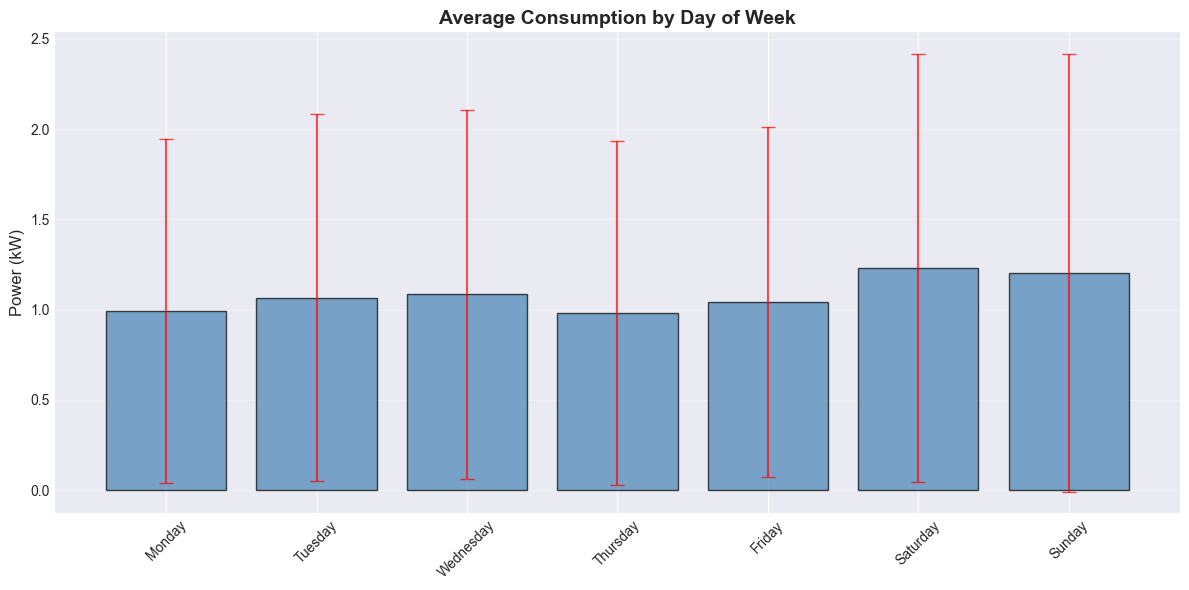


📊 Weekday avg: 1.03 kW
📊 Weekend avg: 1.22 kW
📊 Difference: 0.18 kW (-17.7%)


In [16]:
# Day of week analysis
weekly_pattern = df.groupby('DayOfWeek')['Global_active_power'].agg(['mean', 'std'])
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_pattern.index = days

print("📅 WEEKLY CONSUMPTION PATTERNS")
print("="*60)
print(weekly_pattern)

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(days, weekly_pattern['mean'], alpha=0.7, color='steelblue', edgecolor='black')
ax.errorbar(days, weekly_pattern['mean'], yerr=weekly_pattern['std'], 
            fmt='none', ecolor='red', capsize=5, alpha=0.7)
ax.set_ylabel('Power (kW)', fontsize=12)
ax.set_title('Average Consumption by Day of Week', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Weekend vs Weekday
weekend_avg = df[df['IsWeekend'] == 1]['Global_active_power'].mean()
weekday_avg = df[df['IsWeekend'] == 0]['Global_active_power'].mean()

print(f"\n📊 Weekday avg: {weekday_avg:.2f} kW")
print(f"📊 Weekend avg: {weekend_avg:.2f} kW")
print(f"📊 Difference: {abs(weekday_avg - weekend_avg):.2f} kW ({((weekday_avg - weekend_avg)/weekday_avg*100):.1f}%)")

**Sub-metering Analysis (Identify Waste Areas)**

🏠 ENERGY CONSUMPTION BY AREA
Kitchen      : 2,305,602 Wh (12.6%)
Laundry      : 2,672,847 Wh (14.6%)
AC/Heater    : 13,316,045 Wh (72.8%)


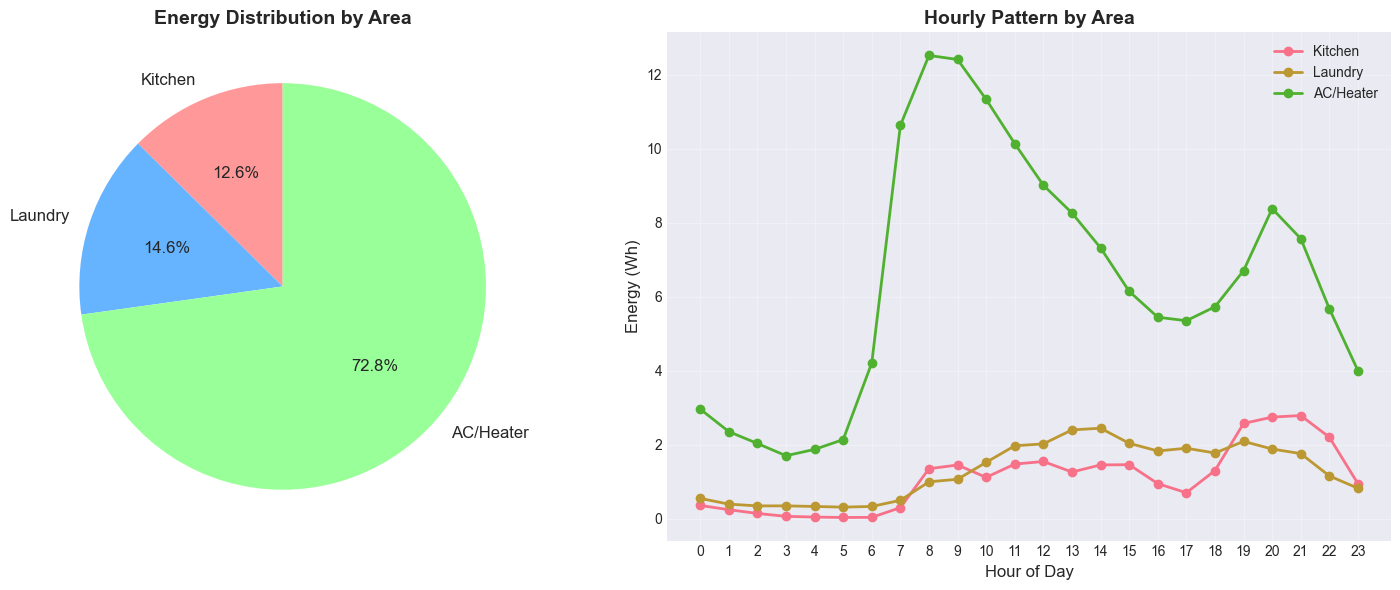


🎯 AC/Heater (Sub_metering_3) is the biggest consumer!
   Potential waste area for anomaly detection!


In [17]:
# Sub-metering breakdown
sub_cols = ['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
sub_names = ['Kitchen', 'Laundry', 'AC/Heater']

# Total consumption by area
totals = df[sub_cols].sum()
totals.index = sub_names

print("🏠 ENERGY CONSUMPTION BY AREA")
print("="*60)
for name, total in totals.items():
    pct = (total / totals.sum()) * 100
    print(f"{name:12} : {total:,.0f} Wh ({pct:.1f}%)")

# Visualize pie chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Pie chart
colors = ['#ff9999', '#66b3ff', '#99ff99']
ax1.pie(totals, labels=sub_names, autopct='%1.1f%%', colors=colors, 
        startangle=90, textprops={'fontsize': 12})
ax1.set_title('Energy Distribution by Area', fontsize=14, fontweight='bold')

# Hourly pattern by sub-meter
hourly_sub = df.groupby('Hour')[sub_cols].mean()
hourly_sub.columns = sub_names

for name in sub_names:
    ax2.plot(hourly_sub.index, hourly_sub[name], marker='o', label=name, linewidth=2)

ax2.set_xlabel('Hour of Day', fontsize=12)
ax2.set_ylabel('Energy (Wh)', fontsize=12)
ax2.set_title('Hourly Pattern by Area', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xticks(range(0, 24))

plt.tight_layout()
plt.show()

print(f"\n🎯 AC/Heater (Sub_metering_3) is the biggest consumer!")
print(f"   Potential waste area for anomaly detection!")

**Identify Potential Waste Patterns**

In [18]:
# High consumption during low-activity hours (potential waste)
print("🚨 POTENTIAL WASTE DETECTION")
print("="*60)

# Define "low activity hours" (Night: 0-6 AM)
night_hours = df[(df['Hour'] >= 0) & (df['Hour'] < 6)]

# High consumption threshold (75th percentile)
threshold = df['Global_active_power'].quantile(0.75)

# Find waste events
waste_events = night_hours[night_hours['Global_active_power'] > threshold]

print(f"Total night hours: {len(night_hours):,}")
print(f"High consumption threshold: {threshold:.2f} kW")
print(f"Waste events detected: {len(waste_events):,} ({len(waste_events)/len(night_hours)*100:.2f}%)")
print(f"\nAverage waste consumption: {waste_events['Global_active_power'].mean():.2f} kW")
print(f"Max waste event: {waste_events['Global_active_power'].max():.2f} kW")

# Sample waste events
print("\n📋 Sample Waste Events:")
print(waste_events[['Global_active_power', 'Hour', 'DayOfWeek', 'Sub_metering_3']].head(10))

🚨 POTENTIAL WASTE DETECTION
Total night hours: 518,760
High consumption threshold: 1.52 kW
Waste events detected: 23,361 (4.50%)

Average waste consumption: 2.30 kW
Max waste event: 10.29 kW

📋 Sample Waste Events:
                     Global_active_power  Hour  DayOfWeek  Sub_metering_3
Datetime                                                                 
2006-12-17 00:02:00                3.038     0          6             0.0
2006-12-17 00:03:00                2.974     0          6             0.0
2006-12-17 00:04:00                2.846     0          6             0.0
2006-12-17 00:05:00                2.848     0          6             0.0
2006-12-17 00:06:00                2.858     0          6             0.0
2006-12-17 00:07:00                2.472     0          6             0.0
2006-12-17 00:10:00                2.608     0          6             0.0
2006-12-17 00:11:00                2.598     0          6             0.0
2006-12-17 00:12:00                2.560     

**Save Processed Data**

In [19]:
# Save cleaned hourly data for modeling
output_path = r"D:\REHAAN\1. Ml Projects\6. Campus Energy Waste Detection\data\processed_data.csv"

print("💾 Saving processed data...")
df_hourly.to_csv(output_path)

print(f"✅ Saved to: {output_path}")
print(f"   Shape: {df_hourly.shape}")
print(f"   Size: {df_hourly.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n📊 SUMMARY STATISTICS")
print("="*60)
print(df_hourly.describe())

💾 Saving processed data...
✅ Saved to: D:\REHAAN\1. Ml Projects\6. Campus Energy Waste Detection\data\processed_data.csv
   Shape: (34589, 15)
   Size: 3.69 MB

📊 SUMMARY STATISTICS
       Global_active_power  Global_reactive_power       Voltage  \
count         34589.000000           34589.000000  34589.000000   
mean              1.086200               0.123326    240.841505   
std               0.894942               0.067221      2.999127   
min               0.124000               0.000000    225.834500   
25%               0.341267               0.077667    239.197167   
50%               0.799533               0.106767    240.984500   
75%               1.574967               0.149367    242.691833   
max               6.560533               0.774333    251.902000   

       Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  \
count      34589.000000    34589.000000    34589.000000    34589.000000   
mean           4.604360        1.110951        1.287914        6